In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [22]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [23]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [24]:
# Add time of day as a feature
df["Hour"] = df["Time"] / 3600 % 24

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

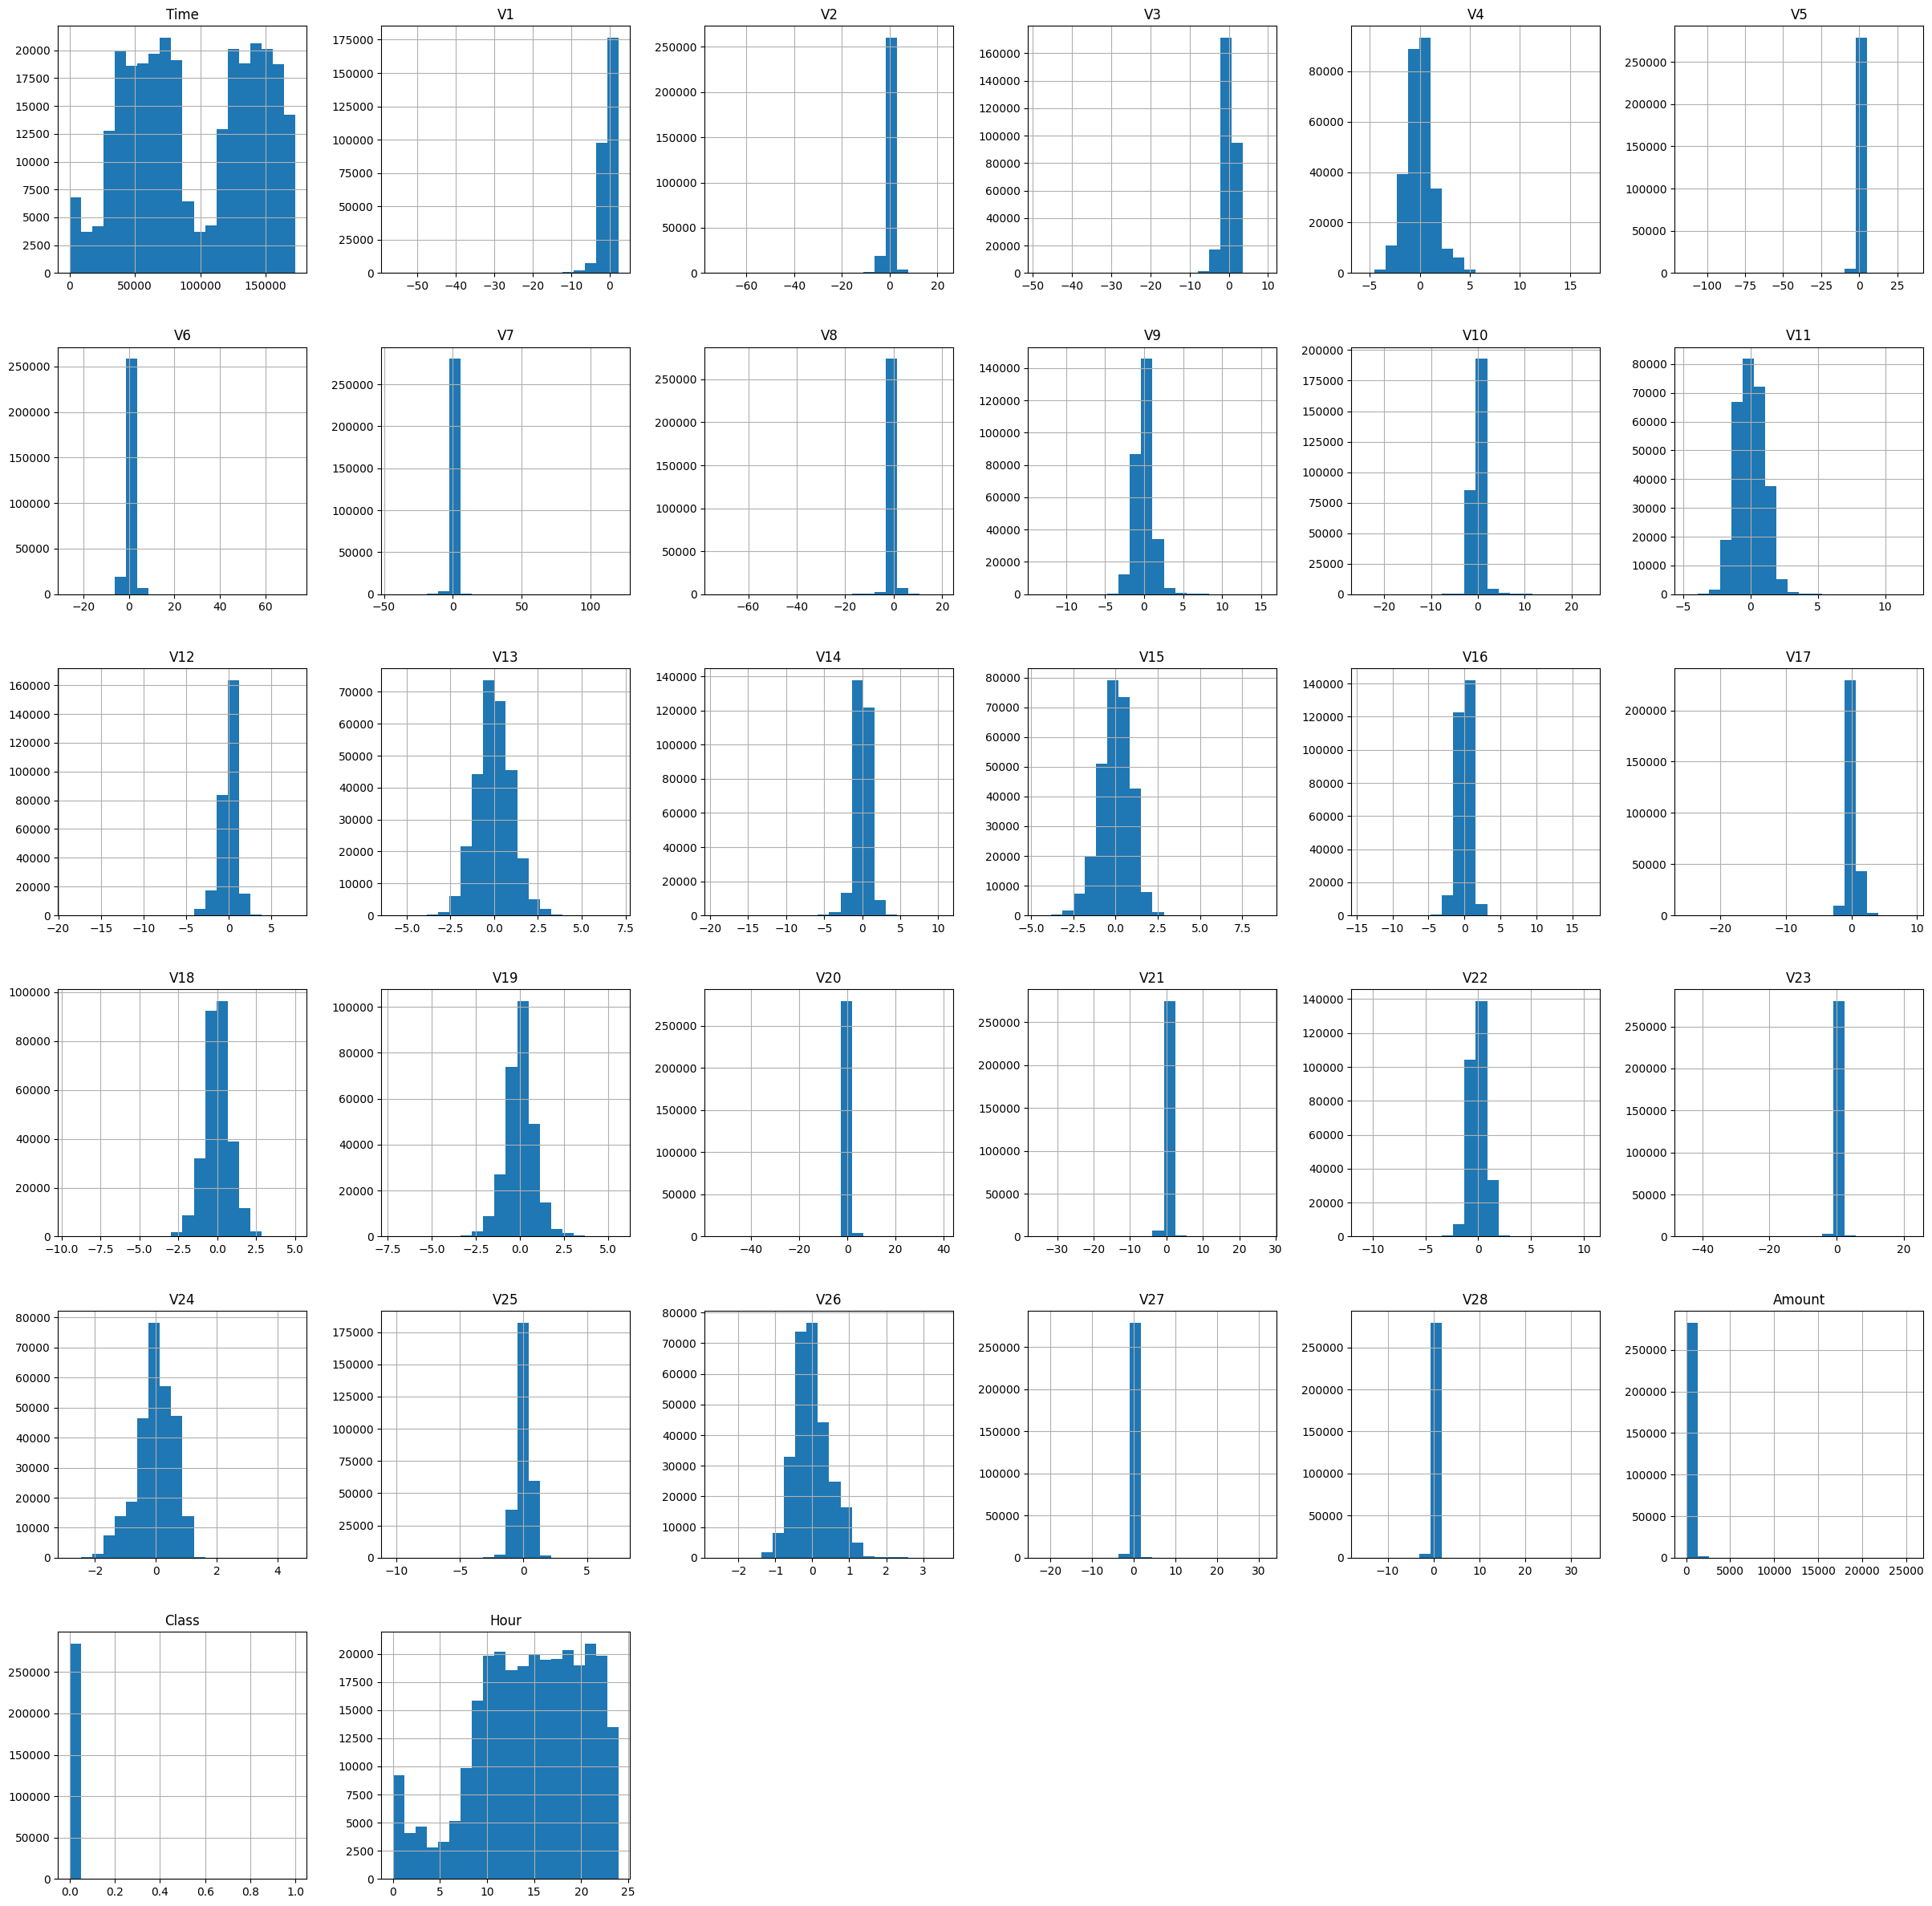

In [25]:
df.hist(bins=20, figsize=(30, 30))

In [26]:
# Split the data into train/val/test 0.6/0.2/0.2

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp)
POS_WEIGHT_RATIO = (y_train == 0).sum() / (y_train == 1).sum() # For cost-sensitive learning

In [27]:
# Preprocessing
# Columns V1-V28 have already been preprocessed

preprocessor = ColumnTransformer(
    transformers=[
        ("time_and_hour_scaler", MinMaxScaler(), ["Time", "Hour"]),
        ("amount_scaler", RobustScaler(), ["Amount"])
    ],
    remainder="passthrough"
)

In [28]:
# Resampling methods for dealing with the imbalance of fraudulant and non-fraudulant data.

resampling_methods = {
    "baseline": None,
    "smote": SMOTE(random_state=1),
    "undersampling": RandomUnderSampler(random_state=1),
    "cost-sensitive": POS_WEIGHT_RATIO
}

In [29]:
# Hyperparameters

param_grid = {
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__n_estimators": [100, 200, 300, 500]
}

In [30]:
def create_pipeline(model, resample_name, resample_method, preprocessor):
    if resample_name == "baseline":
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])
    elif resample_name == "cost-sensitive":
        model.set_params(scale_pos_weight=resample_method)
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])
    else:
        pipeline = ImbPipeline([
            ("preprocessor", preprocessor),
            ("resampler", resample_method),
            ("classifier", model)
        ])
    return pipeline

In [ ]:
# Create and evaluate the models

results = []
model = XGBClassifier(random_state=1, verbosity=1, n_jobs=-1)
model_name = "xgboost"

for resample_name, resample_method in resampling_methods.items():
    pipeline = create_pipeline(model, resample_name, resample_method, preprocessor)

    random_search = RandomizedSearchCV(pipeline, param_grid, scoring="f1", cv=5, n_iter=50, random_state=1, verbose=0) # change to verbose=2 for more clarity
    random_search.fit(X_train, y_train)
    best_pipeline = random_search.best_estimator_
    
    y_pred = best_pipeline.predict(X_test)
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    best_params = random_search.best_params_

    result = {
        "model": model_name,
        "resample": resample_name,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    result.update(best_params)

    results.append(result)
    print("done")

results_df = pd.DataFrame(results)
print(results_df)

In [31]:
# Use the val data to find the optimal threshold for flagging a transaction as fraud using the tuned hyperparams

OPTIMAL_N_ESTIMATORS = 500
OPTIMAL_MAX_DEPTH = 5
OPTIMAL_LEARNING_RATE = 0.2
RESAMPLING = "smote"  # Options: "baseline", "smote", "undersampling", "cost-sensitive"
final_pos_weight_ratio = None

if RESAMPLING == "smote":
    X_train_resampled, y_train_resampled = SMOTE(random_state=1).fit_resample(X_train, y_train)
elif RESAMPLING == "undersampling":
    X_train_resampled, y_train_resampled = RandomUnderSampler(random_state=1).fit_resample(X_train, y_train)
elif RESAMPLING == "cost-sensitive":
    X_train_resampled, y_train_resampled = X_train, y_train
    final_pos_weight_ratio = POS_WEIGHT_RATIO
else:
    X_train_resampled, y_train_resampled = X_train, y_train


model = XGBClassifier(random_state=1, verbosity=1, n_jobs=-1, scale_pos_weight=final_pos_weight_ratio,
                      n_estimators=OPTIMAL_N_ESTIMATORS, max_depth=OPTIMAL_MAX_DEPTH, learning_rate=OPTIMAL_LEARNING_RATE)
model.fit(X_train_resampled, y_train_resampled)
y_proba_val = model.predict_proba(X_val)[:, 1]

threshold_results = []
thresholds = np.arange(0, 0.9, 0.01)
for threshold in thresholds:
   y_pred_val = (y_proba_val >= threshold).astype(int)
   
   precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average="binary")
   
   threshold_results.append({
       "threshold": threshold,
       "precision": precision,
       "recall": recall,
       "f1": f1
   })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string())

optimal_f1_idx = threshold_df["f1"].idxmax()
print(f"Optimal probability threshold for max F1: {threshold_df.iloc[optimal_f1_idx]["threshold"]:.3f} (F1: {threshold_df.iloc[optimal_f1_idx]["f1"]:.3f})")

    threshold  precision    recall        f1
0        0.00   0.001720  1.000000  0.003435
1        0.01   0.524691  0.867347  0.653846
2        0.02   0.617647  0.857143  0.717949
3        0.03   0.661290  0.836735  0.738739
4        0.04   0.700855  0.836735  0.762791
5        0.05   0.729730  0.826531  0.775120
6        0.06   0.743119  0.826531  0.782609
7        0.07   0.743119  0.826531  0.782609
8        0.08   0.750000  0.826531  0.786408
9        0.09   0.757009  0.826531  0.790244
10       0.10   0.764151  0.826531  0.794118
11       0.11   0.786408  0.826531  0.805970
12       0.12   0.801980  0.826531  0.814070
13       0.13   0.810000  0.826531  0.818182
14       0.14   0.818182  0.826531  0.822335
15       0.15   0.818182  0.826531  0.822335
16       0.16   0.816327  0.816327  0.816327
17       0.17   0.824742  0.816327  0.820513
18       0.18   0.833333  0.816327  0.824742
19       0.19   0.833333  0.816327  0.824742
20       0.20   0.833333  0.816327  0.824742
21       0

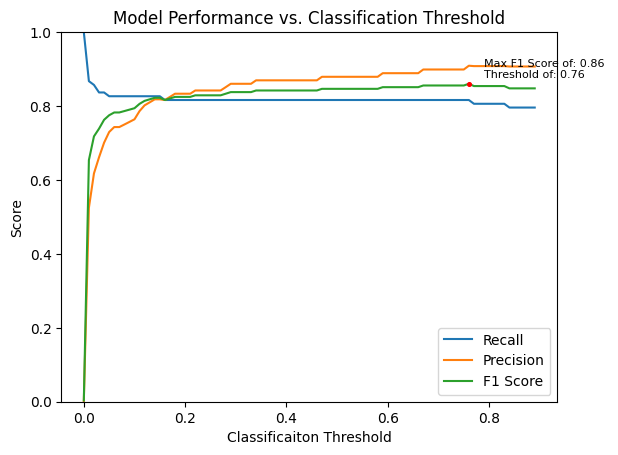

In [32]:
# Plot recall, precision, and F1 with respect to threshold

fig, ax = plt.subplots()
ax.set_ylim(0, 1)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall") 
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision") 
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1 Score")

max_f1_threshold = threshold_df.iloc[optimal_f1_idx]["threshold"]
max_f1 = threshold_df.iloc[optimal_f1_idx]["f1"]
ax.scatter(max_f1_threshold, max_f1, color="red", s=7, zorder=4)
ax.annotate(f"Max F1 Score of: {max_f1:.2f} \nThreshold of: {max_f1_threshold:.2f}",
            (max_f1_threshold, max_f1),
            xytext=(max_f1_threshold+.03, max_f1+.015),
            fontsize=8)

ax.set_title("Model Performance vs. Classification Threshold")
ax.set_xlabel("Classificaiton Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.show()

In [33]:
# Test the model with the optimal threshold

y_proba_test = model.predict_proba(X_test)[:,1]
y_pred_test = (y_proba_test >= max_f1_threshold).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average="binary")
   
final_results = {
   "precision": [precision],
   "recall": [recall],
   "f1": [f1],
}
final_results_df = pd.DataFrame(final_results)
print(final_results_df)

   precision    recall        f1
0   0.956522  0.888889  0.921466


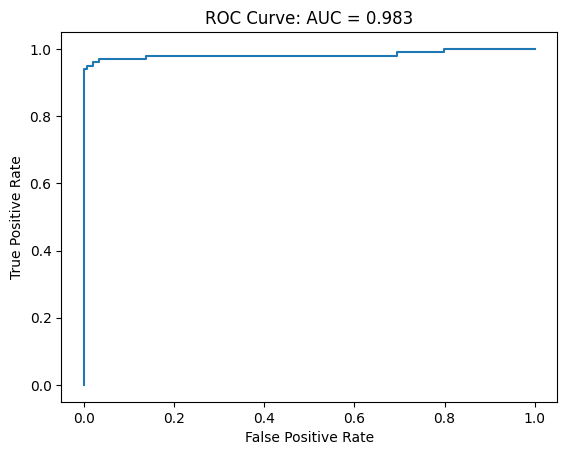

In [34]:
# Plot ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"ROC Curve: AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

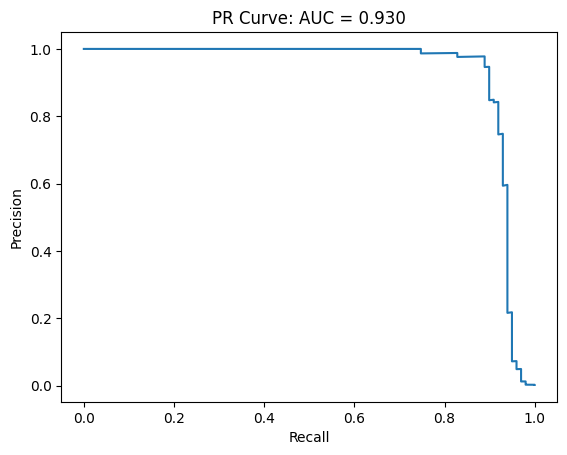

In [35]:
# Plot PR Curve

precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)
plt.plot(recall, precision)
plt.title(f"PR Curve: AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

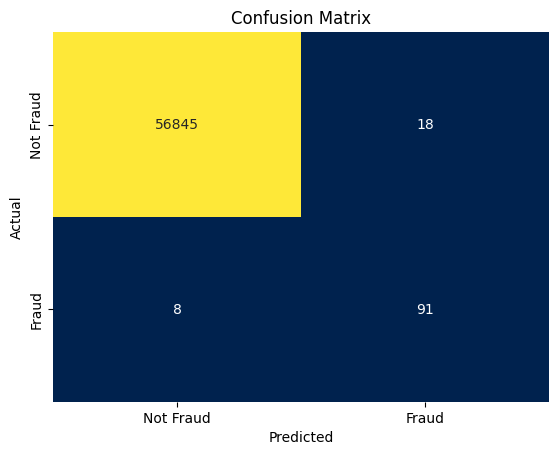

In [36]:
# Confusion Matrix

y_pred = (y_proba_test >= 0.12).astype(int)
cm = confusion_matrix(y_test, y_pred)

labels = ["Not Fraud", "Fraud"]
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis",cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

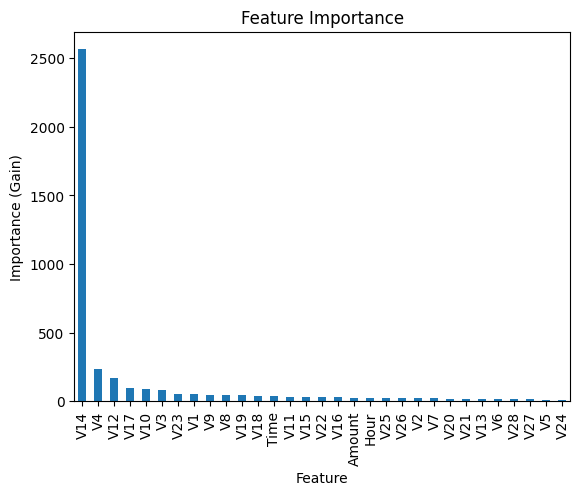

In [37]:
# Identify Important Features

importance = model.get_booster().get_score(importance_type="gain")
feat_imp = pd.Series(importance).sort_values(ascending=False)
feat_imp.plot(kind="bar")

plt.ylabel("Importance (Gain)")
plt.xlabel("Feature")
plt.title("Feature Importance")
plt.show()